In [ ]:
!pip install netCDF4
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [ ]:
file_path = '/content/OR_ABI-L1b-RadC-M6C01_G16_s20231592011183_e20231592013555_c20231592014004.nc'


In [ ]:
data=nc.Dataset(file_path, 'r')
print(data)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    naming_authority: gov.nesdis.noaa
    Conventions: CF-1.7
    standard_name_vocabulary: CF Standard Name Table (v35, 20 July 2016)
    institution: DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services
    project: GOES
    production_site: RBU
    production_environment: OE
    spatial_resolution: 1km at nadir
    Metadata_Conventions: Unidata Dataset Discovery v1.0
    orbital_slot: GOES-East
    platform_ID: G16
    instrument_type: GOES-R Series Advanced Baseline Imager (ABI)
    scene_id: CONUS
    instrument_ID: FM1
    title: ABI L1b Radiances
    summary: Single reflective band ABI L1b Radiance Products are digital maps of outgoing radiance values at the top of the atmosphere for visible and near-IR bands.
    keywords: SPECTRAL/ENGINEERING > VISIBLE WAVELENGTHS > VISIBLE RADIANCE
   

In [ ]:
data.dimensions

{'y': <class 'netCDF4._netCDF4.Dimension'>: name = 'y', size = 3000,
 'x': <class 'netCDF4._netCDF4.Dimension'>: name = 'x', size = 5000,
 'number_of_time_bounds': <class 'netCDF4._netCDF4.Dimension'>: name = 'number_of_time_bounds', size = 2,
 'band': <class 'netCDF4._netCDF4.Dimension'>: name = 'band', size = 1,
 'number_of_image_bounds': <class 'netCDF4._netCDF4.Dimension'>: name = 'number_of_image_bounds', size = 2,
 'number_of_harmonization_coefficients': <class 'netCDF4._netCDF4.Dimension'>: name = 'number_of_harmonization_coefficients', size = 3,
 'num_star_looks': <class 'netCDF4._netCDF4.Dimension'>: name = 'num_star_looks', size = 24}

In [ ]:
data.variables

{'Rad': <class 'netCDF4._netCDF4.Variable'>
 int16 Rad(y, x)
     _FillValue: 1023
     long_name: ABI L1b Radiances
     standard_name: toa_outgoing_radiance_per_unit_wavelength
     _Unsigned: true
     sensor_band_bit_depth: 10
     valid_range: [   0 1022]
     scale_factor: 0.8121064
     add_offset: -25.936647
     units: W m-2 sr-1 um-1
     resolution: y: 0.000028 rad x: 0.000028 rad
     coordinates: band_id band_wavelength t y x
     grid_mapping: goes_imager_projection
     cell_methods: t: point area: point
     ancillary_variables: DQF
 unlimited dimensions: 
 current shape = (3000, 5000)
 filling on,
 'DQF': <class 'netCDF4._netCDF4.Variable'>
 int8 DQF(y, x)
     _FillValue: -1
     long_name: ABI L1b Radiances data quality flags
     standard_name: status_flag
     _Unsigned: true
     valid_range: [0 4]
     units: 1
     coordinates: band_id band_wavelength t y x
     grid_mapping: goes_imager_projection
     cell_methods: t: point area: point
     flag_values: [0 1 2

In [ ]:
radiance = data.variables['Rad'][:]

In [ ]:
print(radiance)

[[-- -- -- ... 243.68267822265625 242.87057495117188 244.49478149414062]
 [-- -- -- ... 247.74319458007812 248.5552978515625 250.17953491210938]
 [-- -- -- ... 257.48846435546875 257.48846435546875 257.48846435546875]
 ...
 [114.55775451660156 132.42410278320312 138.1088409423828 ...
  46.3408203125 45.528717041015625 46.3408203125]
 [128.3635711669922 128.3635711669922 124.30303955078125 ...
  46.3408203125 46.3408203125 46.3408203125]
 [149.47833251953125 134.04830932617188 137.29673767089844 ...
  46.3408203125 46.3408203125 46.3408203125]]


In [ ]:
new_rad = np.ma.masked_invalid(radiance)
new_rad

masked_array(
  data=[[--, --, --, ..., 243.68267822265625, 242.87057495117188,
         244.49478149414062],
        [--, --, --, ..., 247.74319458007812, 248.5552978515625,
         250.17953491210938],
        [--, --, --, ..., 257.48846435546875, 257.48846435546875,
         257.48846435546875],
        ...,
        [114.55775451660156, 132.42410278320312, 138.1088409423828, ...,
         46.3408203125, 45.528717041015625, 46.3408203125],
        [128.3635711669922, 128.3635711669922, 124.30303955078125, ...,
         46.3408203125, 46.3408203125, 46.3408203125],
        [149.47833251953125, 134.04830932617188, 137.29673767089844, ...,
         46.3408203125, 46.3408203125, 46.3408203125]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]

In [ ]:
# Normalize data to the range 0-255 for grayscale
normalized_rad = (new_rad - np.min(new_rad)) / (np.max(new_rad) - np.min(new_rad)) * 255

cmap = cm.get_cmap('jet')
rgb_image = cmap(normalized_rad)

<ipython-input-23-90ba01d1a803>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet')


In [ ]:
# Convert to uint8 (0-255 grayscale values)
grayscale_image = normalized_rad.astype(np.uint8)

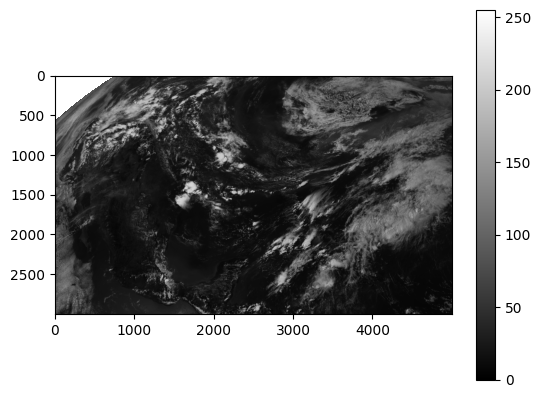

In [ ]:
plt.imshow(grayscale_image, cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
# Normalize data to the range 0-1 for the colormap
norm_data_II = (new_rad - np.min(new_rad)) / (np.max(new_rad) - np.min(new_rad))

In [ ]:
cmap_II = cm.get_cmap('jet')

rgb_image = cmap_II(norm_data_II)  #MxNx4 array (RGBA)

# Convert RGBA to RGB by dropping the alpha channel
rgb_image = rgb_image[:, :, :3]


<ipython-input-27-1194a0a961d9>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_II = cm.get_cmap('jet')


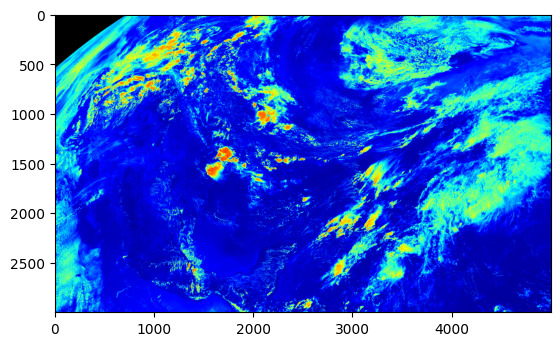

In [ ]:
# Display the image
plt.imshow(rgb_image)
plt.show()
plt.axis